> **Mitra AI Projects — Course Notebook**  
> This is a real-world applied notebook from the AIML-Engineering-Lab.  
> Read each cell, run the code, and modify it to experiment.  
> Your work saves automatically in your browser.

---


# Naive Bayes & LDA: Jira Bug Ticket Routing## Multi-Class Classification with Probabilistic Models**Project:** 008 — The AI Engineering Lab  **Objective:** Route bug tickets to correct teams using Naive Bayes and LDA.  **Advanced Concepts:** Bayes' theorem, class-conditional distributions, LDA as dimensionality reduction, Fisher's criterion.

---## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline

COLORS = {'primary': '#0D47A1', 'secondary': '#FF6F00', 'accent': '#2E7D32', 'highlight': '#C62828'}
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
print('Libraries loaded.')

Libraries loaded.


---## 2. Load Data8,000 Jira bug tickets across 6 teams.

In [2]:
df = pd.read_csv('../data/jira_bug_routing.csv')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'\nTarget distribution:\n{df.iloc[:, -1].value_counts().to_string()}')
df.head()

Shape: (8000, 7)
Columns: ['hardware_keywords', 'software_keywords', 'urgency_score', 'log_lines_attached', 'reporter_seniority', 'hour_of_day', 'category']

Target distribution:
category
Software         2000
Hardware         1600
Firmware         1400
Performance      1200
Documentation    1000
Security          800


,hardware_keywords,software_keywords,urgency_score,log_lines_attached,reporter_seniority,hour_of_day,category
0,5,5,5.2,96,4,15,Firmware
1,5,2,3.1,60,4,10,Firmware
2,4,2,3.6,36,3,15,Firmware
3,1,11,3.8,37,2,2,Software
4,3,6,4.0,68,4,6,Software


In [3]:
target_col = df.columns[-1]
feature_cols = [c for c in df.columns if c != target_col]
le = LabelEncoder()
y = le.fit_transform(df[target_col])
X = df[feature_cols].select_dtypes(include=[np.number])
feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
print(f'Features: {feature_names}')
print(f'Classes: {le.classes_.tolist()}')
print(f'Train: {X_train_s.shape}, Test: {X_test_s.shape}')

Features: ['hardware_keywords', 'software_keywords', 'urgency_score', 'log_lines_attached', 'reporter_seniority', 'hour_of_day']
Classes: ['Documentation', 'Firmware', 'Hardware', 'Performance', 'Security', 'Software']
Train: (6400, 6), Test: (1600, 6)


---## 3. EDA

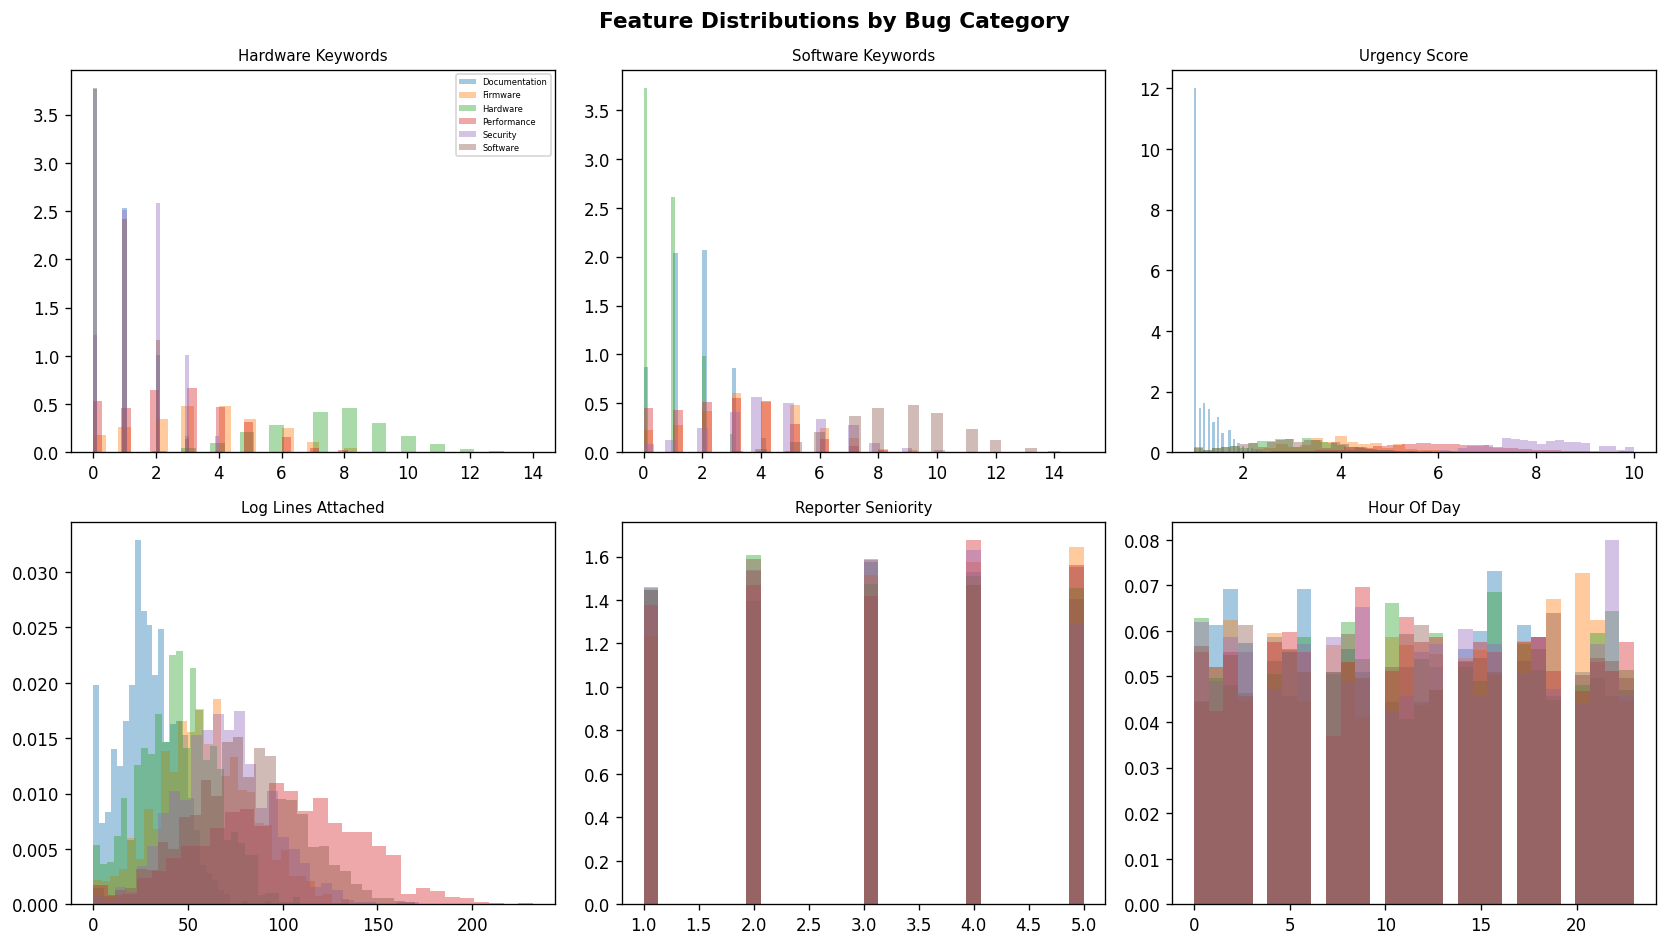

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
n_features = min(6, len(feature_names))
for i in range(n_features):
    ax = axes[i // 3, i % 3]
    col = feature_names[i]
    for cls_idx, cls_name in enumerate(le.classes_):
        subset = X[y == cls_idx][col]
        ax.hist(subset, bins=30, alpha=0.4, label=cls_name, density=True)
    ax.set_title(col.replace('_', ' ').title(), fontsize=9)
    if i == 0:
        ax.legend(fontsize=5)
plt.suptitle('Feature Distributions by Bug Category', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/proj1_jira_eda.png', dpi=150, bbox_inches='tight')
plt.show()

---## 4. Gaussian Naive Bayes

In [5]:
gnb = GaussianNB()
gnb.fit(X_train_s, y_train)
y_pred_gnb = gnb.predict(X_test_s)
gnb_acc = accuracy_score(y_test, y_pred_gnb)

print(f'Gaussian NB Accuracy: {gnb_acc:.3f}')
print(classification_report(y_test, y_pred_gnb, target_names=le.classes_))

Gaussian NB Accuracy: 0.875
               precision    recall  f1-score   support

Documentation       0.98      0.99      0.98       200
     Firmware       0.75      0.76      0.76       280
     Hardware       0.91      0.94      0.93       320
  Performance       0.78      0.66      0.72       240
     Security       0.84      0.87      0.86       160
     Software       0.94      0.98      0.96       400

     accuracy                           0.88      1600
    macro avg       0.87      0.87      0.87      1600
 weighted avg       0.87      0.88      0.87      1600



---## 5. LDA — Classification & Dimensionality Reduction

In [6]:
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_s, y_train)
y_pred_lda = lda.predict(X_test_s)
lda_acc = accuracy_score(y_test, y_pred_lda)

print(f'LDA Accuracy: {lda_acc:.3f}')
print(classification_report(y_test, y_pred_lda, target_names=le.classes_))

LDA Accuracy: 0.857
               precision    recall  f1-score   support

Documentation       0.90      1.00      0.95       200
     Firmware       0.75      0.70      0.72       280
     Hardware       0.90      0.93      0.91       320
  Performance       0.78      0.62      0.69       240
     Security       0.79      0.88      0.83       160
     Software       0.93      0.97      0.95       400

     accuracy                           0.86      1600
    macro avg       0.84      0.85      0.84      1600
 weighted avg       0.85      0.86      0.85      1600



---## 6. LDA vs PCA Projection

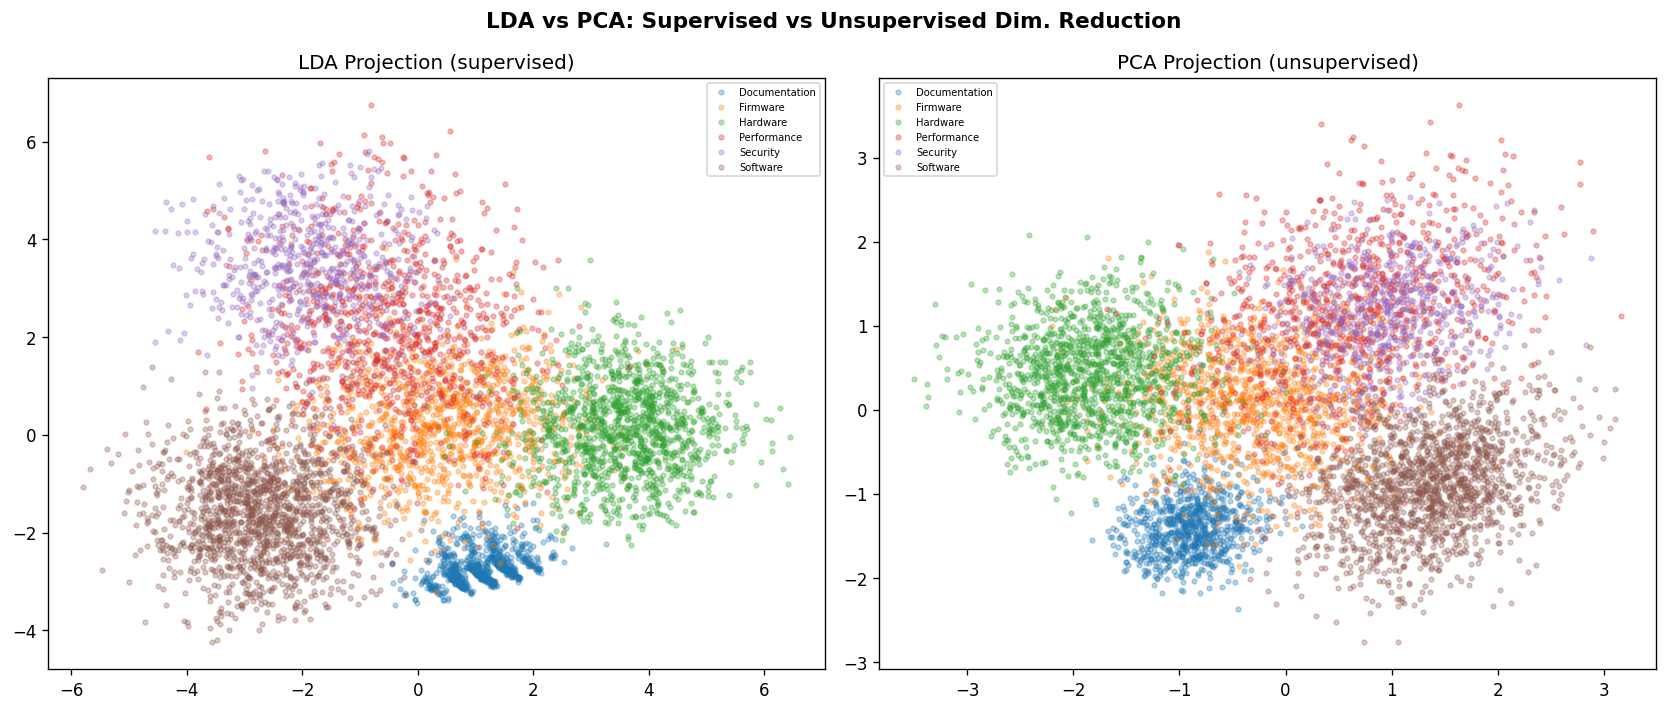

In [7]:
n_components = min(2, len(le.classes_) - 1, X_train_s.shape[1])
lda_proj = LinearDiscriminantAnalysis(n_components=n_components)
X_lda = lda_proj.fit_transform(X_train_s, y_train)
X_pca = PCA(n_components=2).fit_transform(X_train_s)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for cls_idx, cls_name in enumerate(le.classes_):
    mask = y_train == cls_idx
    if n_components >= 2:
        axes[0].scatter(X_lda[mask, 0], X_lda[mask, 1], alpha=0.3, s=8, label=cls_name)
    else:
        axes[0].scatter(X_lda[mask, 0], np.random.normal(0, 0.1, mask.sum()), alpha=0.3, s=8, label=cls_name)
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=0.3, s=8, label=cls_name)
axes[0].set_title('LDA Projection (supervised)'); axes[0].legend(fontsize=6)
axes[1].set_title('PCA Projection (unsupervised)'); axes[1].legend(fontsize=6)
plt.suptitle('LDA vs PCA: Supervised vs Unsupervised Dim. Reduction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/proj1_jira_lda_vs_pca.png', dpi=150, bbox_inches='tight')
plt.show()

---## 7. Confusion Matrix & Summary

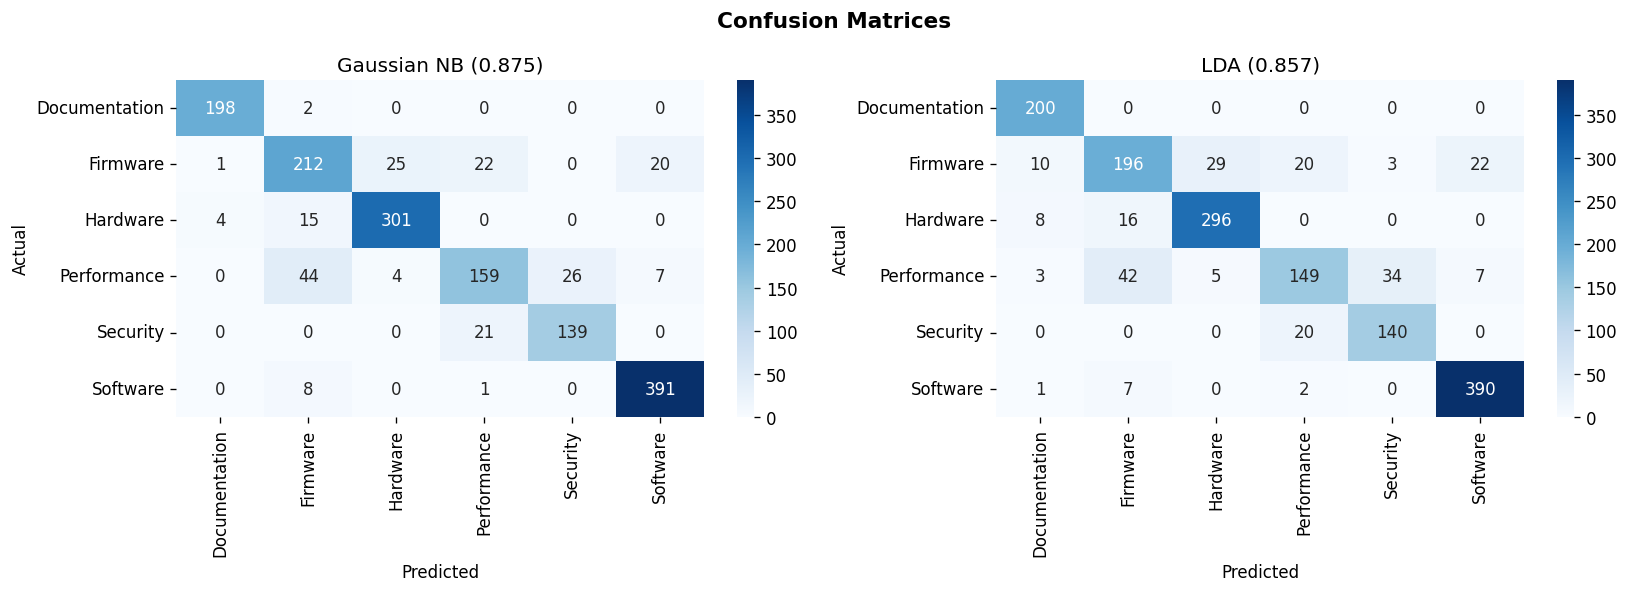


Gaussian NB: 0.875 | LDA: 0.857
Notebook complete.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, y_pred, title in zip(axes, [y_pred_gnb, y_pred_lda], [f'Gaussian NB ({gnb_acc:.3f})', f'LDA ({lda_acc:.3f})']):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=le.classes_, yticklabels=le.classes_)
    ax.set_title(title); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrices', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/proj1_jira_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nGaussian NB: {gnb_acc:.3f} | LDA: {lda_acc:.3f}')
print('Notebook complete.')